# PBC2 joint model with time-varying prothrombin

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

ROOT = Path.cwd().resolve()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

In [2]:
from jmstate.types import ModelData

torch.manual_seed(42)
pbc2 = pd.read_csv(ROOT / "data" / "pbc2.csv")
pbc2["drug"] = pbc2["drug"].map({"placebo": 0, "D-penicil": 1})
pbc2["serBilir"] = np.log(pbc2["serBilir"])

trajectories = []
censoring = []
times = []
markers = []
covariates = []
prothrombins = []
for subject, (_, group) in enumerate(pbc2.groupby("id", sort=True)):
    event = int(group["status2"].iloc[0])
    event_time = float(group["years"].iloc[0]) / 10
    subject_times = torch.tensor(
        group["year"].to_numpy(), dtype=torch.float32
    ) / 10
    trajectory = [(0.0, 0)]
    if event:
        trajectory.append((event_time, 1))
    trajectories.append(trajectory)
    censoring.append(max(event_time, subject_times[-1].item()))
    times.append(subject_times)
    markers.append(torch.tensor(group[["serBilir"]].to_numpy(), dtype=torch.float32))
    prothrombins.append(
        torch.tensor(group["prothrombin"].to_numpy(), dtype=torch.float32)
    )
    covariates.append(
        torch.tensor(
            (
                subject,
                group["drug"].iloc[0],
                group["age"].iloc[0],
                subject_times[-1].item(),
            ),
            dtype=torch.float32,
        )
    )

pad = nn.utils.rnn.pad_sequence
prothrombin = torch.cat(prothrombins)
PROTHROMBIN_MEAN = prothrombin.mean()
PROTHROMBIN_STD = prothrombin.std()
PROTHROMBIN_TIMES = pad(times, batch_first=True, padding_value=torch.inf)
PROTHROMBIN_VALUES = pad(
    [(values - PROTHROMBIN_MEAN) / PROTHROMBIN_STD for values in prothrombins],
    batch_first=True,
)
covariates = torch.stack(covariates)
covariates[:, 2] = (covariates[:, 2] - covariates[:, 2].mean()) / covariates[
    :, 2
].std()
data = ModelData(
    covariates,
    pad(times, batch_first=True, padding_value=torch.nan),
    pad(markers, batch_first=True, padding_value=torch.nan),
    trajectories,
    torch.tensor(censoring, dtype=torch.float32)[:, None],
)

In [3]:
from jmstate.functions.base_hazards import Exponential
from jmstate.types import ModelDesign, ModelParameters, PrecisionParameters

DIM = 1
LEARNING_RATE = 0.01
SUBJECT_INDEX = 3
DRUG_INDEX = 4
AGE_INDEX = 5
CUTOFF_INDEX = 6


def indiv_params_fn(fixed: torch.Tensor, x: torch.Tensor, b: torch.Tensor):
    features = x.expand(*b.shape[:-2], *x.shape)
    prothrombin_coef = fixed[2].expand(*b.shape[:-1], 1)
    return torch.cat((fixed[:2] + b, prothrombin_coef, features), dim=-1)


def prothrombin_at(
    t: torch.Tensor, subject: torch.Tensor, cutoff: torch.Tensor
):
    path_times = PROTHROMBIN_TIMES[subject]
    path_values = PROTHROMBIN_VALUES[subject]
    available_times = torch.where(
        path_times <= cutoff[..., None], path_times, torch.inf
    )
    right = torch.searchsorted(
        available_times.contiguous(), t.contiguous()
    ).clamp(max=path_times.shape[-1] - 1)
    left = (right - 1).clamp(min=0)
    left_time = available_times.gather(-1, left)
    right_time = available_times.gather(-1, right)
    left_value = path_values.gather(-1, left)
    right_value = path_values.gather(-1, right)
    width = right_time - left_time
    weight = torch.where(
        torch.isfinite(width) & (width > 0), (t - left_time) / width, 0
    ).clamp(0, 1)
    return left_value + weight * (right_value - left_value)


def regression_fn(t: torch.Tensor, indiv_params: torch.Tensor):
    t = torch.broadcast_to(t, (*indiv_params.shape[:-1], t.shape[-1]))
    subject = indiv_params[..., SUBJECT_INDEX].long()
    prothrombin = prothrombin_at(t, subject, indiv_params[..., CUTOFF_INDEX])
    mean = (
        indiv_params[..., 0, None]
        + indiv_params[..., 1, None] * t
        + indiv_params[..., 2, None] * prothrombin
    )
    return mean.unsqueeze(-1)


def initial_fixed_effects(data: ModelData):
    valid = torch.isfinite(data.t) & torch.isfinite(data.y[..., 0])
    time = torch.nan_to_num(data.t)
    subject = data.x[:, 0].long()
    prothrombin = prothrombin_at(time, subject, data.x[:, -1])
    design_matrix = torch.stack(
        (torch.ones_like(time[valid]), time[valid], prothrombin[valid]), dim=1
    )
    return torch.linalg.lstsq(
        design_matrix, data.y[..., 0][valid]
    ).solution


def make_design(data: ModelData):
    marker_center = torch.nanmean(data.y)

    def survival_fn(t: torch.Tensor, indiv_params: torch.Tensor):
        current_value = regression_fn(t, indiv_params) - marker_center
        drug = indiv_params[..., None, DRUG_INDEX].unsqueeze(-1)
        age = indiv_params[..., None, AGE_INDEX].unsqueeze(-1)
        # Coefficient order: current bilirubin, baseline drug, baseline age.
        return torch.cat(
            (current_value, drug.expand_as(current_value), age.expand_as(current_value)),
            dim=-1,
        )

    return ModelDesign(indiv_params_fn, regression_fn, {(0, 1): survival_fn})


design = make_design(data)


def init_params(data: ModelData):
    return ModelParameters(
        initial_fixed_effects(data),
        PrecisionParameters.from_covariance(torch.eye(2), "diag"),
        PrecisionParameters.from_covariance(torch.eye(DIM), "spherical"),
        {(0, 1): Exponential(0.1)},
        {(0, 1): torch.zeros(3)},
        {},
    )


params = init_params(data)

In [4]:
from jmstate import MultiStateJointModel

torch.manual_seed(42)
optimizer = torch.optim.Adam(params.parameters(), lr=LEARNING_RATE)
model = MultiStateJointModel(
    design,
    params,
    optimizer,
    max_iter=10000,
    window_size=500,
    n_chains=5,
    n_subsample=10,
).fit(data)

Fitting joint model:   0%|          | 0/10000 [00:00<?, ?it/s]

Fitting joint model:   0%|          | 4/10000 [00:00<05:12, 32.01it/s]

Fitting joint model:   0%|          | 8/10000 [00:00<05:05, 32.75it/s]

Fitting joint model:   0%|          | 12/10000 [00:00<05:02, 33.07it/s]

Fitting joint model:   0%|          | 16/10000 [00:00<05:05, 32.66it/s]

...

Fitting joint model:  13%|█▎        | 1312/10000 [00:54<05:39, 25.59it/s]

Fitting joint model:  13%|█▎        | 1315/10000 [00:55<05:44, 25.23it/s]

Fitting joint model:  13%|█▎        | 1318/10000 [00:55<05:36, 25.79it/s]

Fitting joint model:  13%|█▎        | 1321/10000 [00:55<05:38, 25.67it/s]

Fitting joint model:  13%|█▎        | 1322/10000 [00:55<06:03, 23.87it/s]

Computing FIM and Model Selection Criteria:   0%|          | 0/100 [00:00<?, ?it/s]

Computing FIM and Model Selection Criteria:   1%|          | 1/100 [00:00<00:10,  9.36it/s]

Computing FIM and Model Selection Criteria:   4%|▍         | 4/100 [00:00<00:05, 17.19it/s]

Computing FIM and Model Selection Criteria:   7%|▋         | 7/100 [00:00<00:04, 18.92it/s]

Computing FIM and Model Selection Criteria:  10%|█         | 10/100 [00:00<00:04, 19.42it/s]

...

Computing FIM and Model Selection Criteria:  94%|█████████▍| 94/100 [00:04<00:00, 20.58it/s]

Computing FIM and Model Selection Criteria:  97%|█████████▋| 97/100 [00:04<00:00, 20.10it/s]

Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:04<00:00, 20.33it/s]

Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:04<00:00, 20.37it/s]

╭──────────────────────────────────────────── Model Summary ─────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name                  ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ fixed_effects[0]                │ 0.536  │     0.065      │  8.275  │  0.000  │        ***         │ │
│ │ fixed_effects[1]                │ 1.557  │     0.136      │ 11.426  │  0.000  │        ***         │ │
│ │ fixed_effects[2]                │ 0.080  │     0.006      │ 14.112  │  0.000  │        ***         │ │
│ │ random_prec.flat[0]             │ -0.001 │     0.057      │  0.019  │  0.985  │                    │ │
│ │ random_prec.flat[1]             │ -0.546 │     0.068      │  8.076  │  0.000  │        ***         │ │
│ │ noise_prec.flat[0]              │ 1.064  │     0.010      │ 109.567 │  0.000  │        ***         │ │
│ │ base_hazards.(0, 1).log_lmda[0] │ -1.496 │     0.214      │  6.989  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[0]            │ 1.389  │     0.110      │ 12.639  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[1]            │ -0.030 │     0.187      │  0.159  │  0.874  │                    │ │
│ │ link_coefs.(0, 1)[2]            │ 0.654  │     0.079      │  8.277  │  0.000  │        ***         │ │
│ └─────────────────────────────────┴────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: -1562.653                                                                              │
│ AIC: 3145.307                                                                                          │
│ BIC: 3184.581                                                                                          │
│ ────────────────────────────────────────────────────────────────────────────────────────────────────── │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

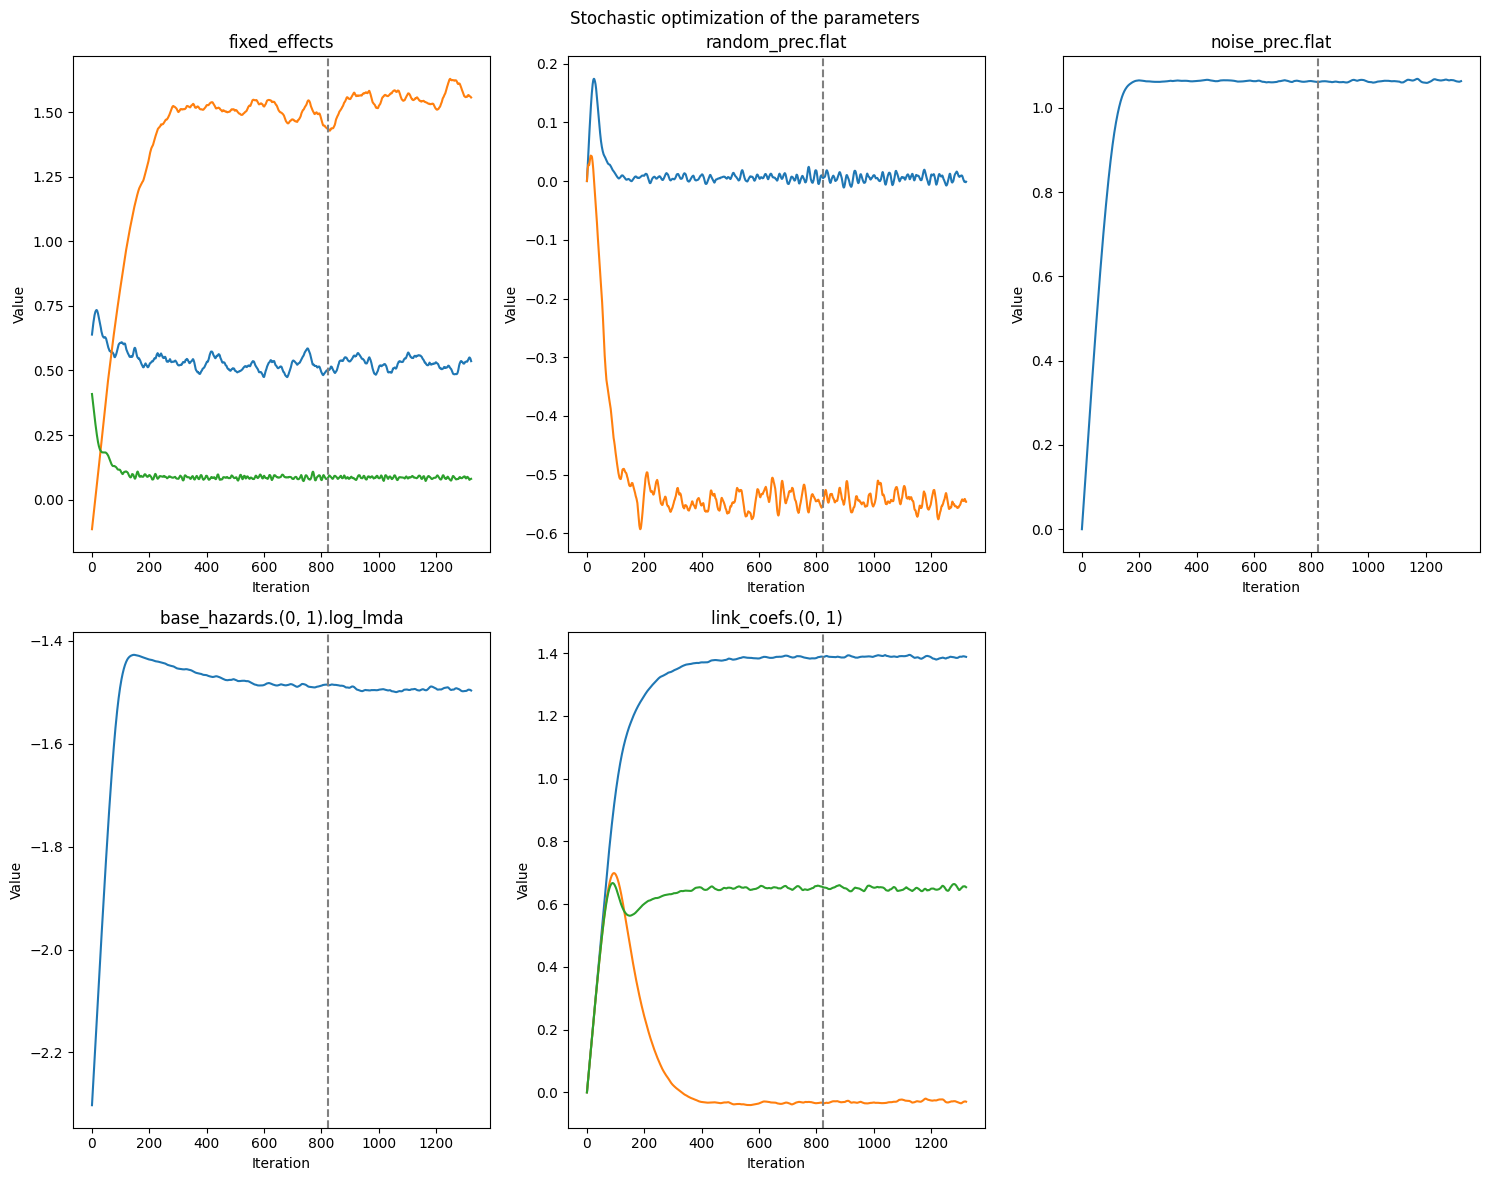

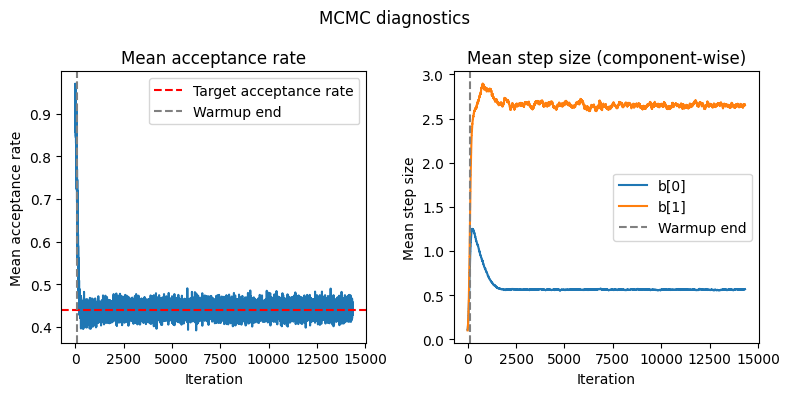

In [5]:
from jmstate.utils import plot_mcmc_diagnostics, plot_params_history

model.compute_summary().summary()

figure, axes = plot_params_history(model, figsize=(15, 12))
convergence = len(model.params_history_) - model.window_size
for axis in axes:
    axis.axvline(convergence, color="gray", linestyle="--")
    if axis.get_legend() is not None:
        axis.get_legend().remove()
figure.savefig(ROOT / "figures" / "pbc2-optimization.pdf")
plt.show()

figure, _ = plot_mcmc_diagnostics(model)
figure.savefig(ROOT / "figures" / "pbc2-diagnostics.pdf")
plt.show()

In [6]:
from dataclasses import replace


def predict_cond_survival(
    model: MultiStateJointModel,
    data_test: ModelData,
    cond_time: float,
    horizons: torch.Tensor,
):
    trajectories_cond = [
        [trajectory[0]]
        + [(time, state) for time, state in trajectory[1:] if time <= cond_time]
        for trajectory in data_test.trajectories
    ]
    last_times = torch.tensor(
        [trajectory[-1][0] for trajectory in trajectories_cond]
    )[:, None]

    y_truncated = data_test.y.clone()
    y_truncated[data_test.t > cond_time] = torch.nan
    x_conditioned = data_test.x.clone()
    x_conditioned[:, -1] = torch.minimum(
        x_conditioned[:, -1], torch.as_tensor(cond_time)
    )
    conditioned_data = replace(
        data_test,
        x=x_conditioned,
        y=y_truncated,
        trajectories=trajectories_cond,
        c=torch.maximum(last_times, cond_time),
    )
    log_survival = model.predict_surv_logps(
        conditioned_data, horizons, n_samples=100
    )
    return log_survival.exp().mean(dim=0)


def observed_states(trajectories: list, horizon: float):
    event = torch.tensor(
        [len(trajectory) > 1 and trajectory[1][0] <= horizon for trajectory in trajectories],
        dtype=torch.float32,
    )
    return torch.stack((1 - event, event), dim=1)


def normalized_brier(predicted: torch.Tensor, observed: torch.Tensor):
    model_score = ((predicted - observed) ** 2).mean()
    baseline = observed.mean(dim=0)
    baseline_score = ((baseline - observed) ** 2).mean()
    return 1 - (model_score / baseline_score).item()


def accuracy(predicted: torch.Tensor, observed: torch.Tensor):
    return (predicted.argmax(dim=1) == observed.argmax(dim=1)).float().mean().item()

In [7]:
from sklearn.model_selection import KFold

N_FOLDS = 5
splitter = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cond_times = torch.linspace(0, data.c.max(), 5)[:-2]
horizons = torch.linspace(0, data.c.max(), 50)
brier_skill = torch.full((N_FOLDS, len(cond_times), len(horizons)), torch.nan)
accuracies = torch.full_like(brier_skill, torch.nan)

torch.manual_seed(42)
for fold, (train_indices, test_indices) in enumerate(splitter.split(data)):
    training_data, test_data = data[train_indices], data[test_indices]
    fold_params = init_params(training_data)
    fold_optimizer = torch.optim.Adam(
        fold_params.parameters(), lr=LEARNING_RATE
    )
    fold_model = MultiStateJointModel(
        make_design(training_data),
        fold_params,
        fold_optimizer,
        max_iter=10000,
        window_size=500,
        n_chains=5,
        n_subsample=10,
    ).fit(training_data)

    for landmark_index, cond_time in enumerate(cond_times):
        survival = predict_cond_survival(
            fold_model, test_data, cond_time, horizons
        )
        at_risk = (test_data.c > cond_time).flatten()
        for horizon_index, horizon in enumerate(horizons):
            predicted = torch.stack(
                (survival[:, horizon_index], 1 - survival[:, horizon_index]), dim=1
            )[at_risk]
            observed = observed_states(test_data.trajectories, horizon)[at_risk]
            brier_skill[fold, landmark_index, horizon_index] = normalized_brier(
                predicted, observed
            )
            accuracies[fold, landmark_index, horizon_index] = accuracy(
                predicted, observed
            )

Fitting joint model:   0%|          | 0/10000 [00:00<?, ?it/s]

Fitting joint model:   0%|          | 3/10000 [00:00<05:40, 29.33it/s]

Fitting joint model:   0%|          | 6/10000 [00:00<05:37, 29.63it/s]

Fitting joint model:   0%|          | 9/10000 [00:00<05:37, 29.64it/s]

Fitting joint model:   0%|          | 12/10000 [00:00<05:37, 29.60it/s]

...

Predicting survival log probabilities:   0%|          | 0/20 [00:00<?, ?it/s]

Predicting survival log probabilities:  30%|███       | 6/20 [00:00<00:00, 51.02it/s]

Predicting survival log probabilities:  60%|██████    | 12/20 [00:00<00:00, 52.34it/s]

Predicting survival log probabilities:  90%|█████████ | 18/20 [00:00<00:00, 51.95it/s]

Predicting survival log probabilities: 100%|██████████| 20/20 [00:00<00:00, 51.65it/s]

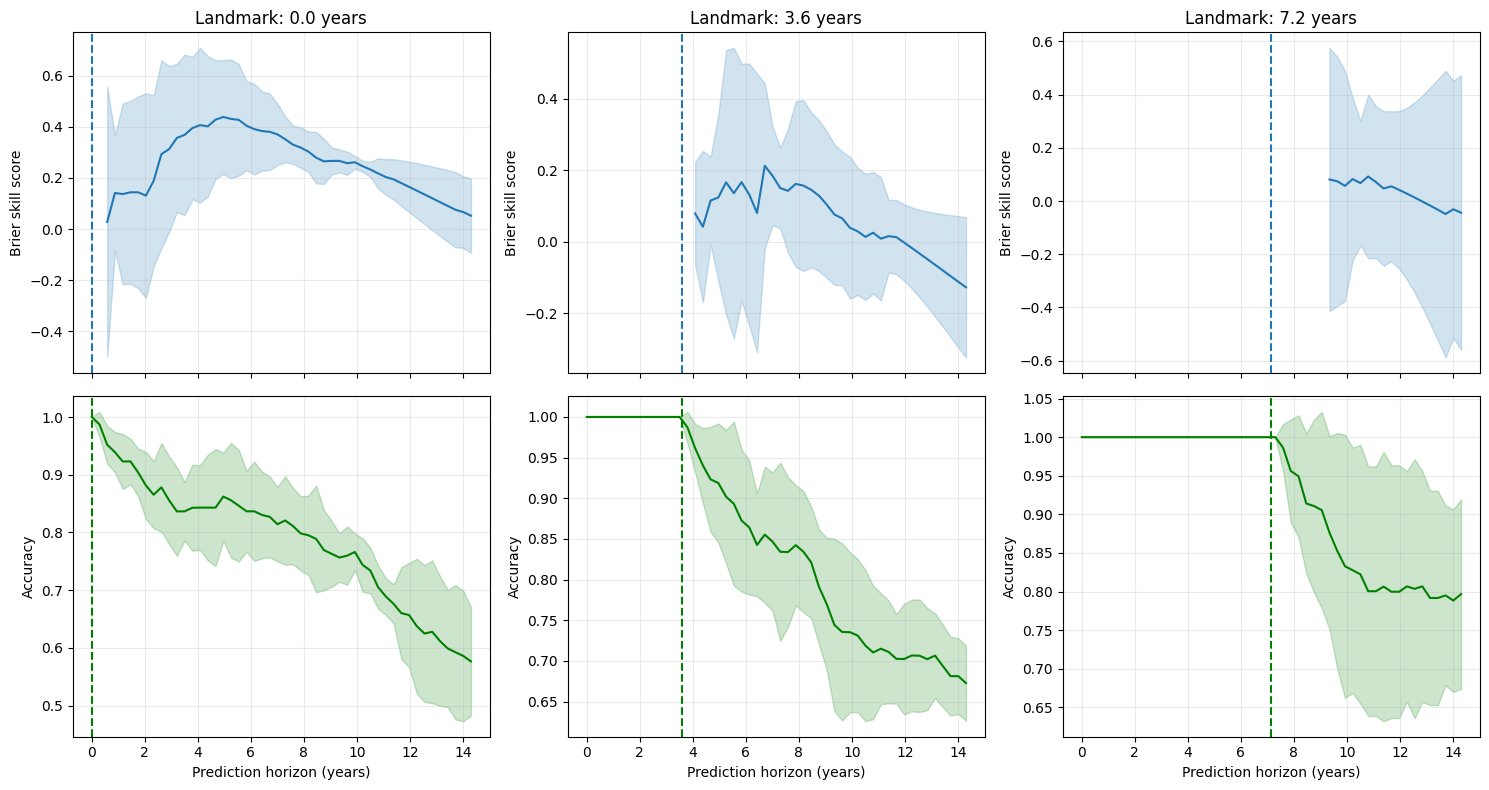

In [8]:
from scipy.stats import norm

q95 = norm.ppf(0.95)
figure, axes = plt.subplots(2, len(cond_times), figsize=(15, 8), sharex=True)
time_in_years = 10 * horizons
colors = ("C0", "green")
for landmark_index, cond_time in enumerate(cond_times):
    for row, (values, label) in enumerate(
        ((brier_skill, "Brier skill score"), (accuracies, "Accuracy"))
    ):
        mean = values[:, landmark_index].mean(dim=0)
        interval = q95 * values[:, landmark_index].std(dim=0)
        axis = axes[row, landmark_index]
        axis.plot(time_in_years, mean, color=colors[row])
        axis.fill_between(
            time_in_years, mean - interval, mean + interval,
            alpha=0.2, color=colors[row]
        )
        axis.axvline(10 * cond_time, color=colors[row], linestyle="--")
        axis.set_ylabel(label)
        axis.grid(alpha=0.25)
    axes[0, landmark_index].set_title(
        f"Landmark: {10 * cond_time:.1f} years"
    )
    axes[1, landmark_index].set_xlabel("Prediction horizon (years)")

figure.tight_layout()
figure.savefig(ROOT / "figures" / "pbc2-accuracy.pdf")
plt.show()